In [1]:
# ============================================================
# 1️⃣ IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# ============================================================
# 2️⃣ LOAD & PREPROCESS MULTI-YEAR NSE DATASET
# ============================================================

df = pd.read_csv("NIFTY_1_Years.csv", encoding="utf-8-sig")

# Clean columns
df.columns = df.columns.str.strip()

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Sort ascending
df = df.sort_values("Date")

# Set index
df.set_index("Date", inplace=True)

# Use Close price
data = df[['Close']]

# Train-Test Split (80-20)
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

print("Training size:", len(train))
print("Testing size :", len(test))

Training size: 197
Testing size : 50


In [3]:
# ============================================================
# 3️⃣ SCALING FOR DEEP LEARNING
# ============================================================

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

In [4]:
# ============================================================
# 4️⃣ HELPER FUNCTIONS
# ============================================================

def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)


def evaluate_model(actual, predicted, name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    return rmse, mae, r2


time_steps = 60

In [5]:
# ==============================
# ARIMA + LSTM (Safe + Corrected)
# ==============================

time_steps = 20

# --- ARIMA ---
arima_model = ARIMA(train['Close'], order=(3,1,1))
arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(steps=len(test))

# --- Residuals ---
residuals = test['Close'].values - arima_forecast.values
residuals = residuals.reshape(-1,1)

# Check if enough data
if len(residuals) <= time_steps:
    print("Not enough test data for LSTM residual modeling.")
    
    # Avoid NameError later
    rmse1, mae1, r21 = None, None, None

else:
    # --- Scale residuals ---
    res_scaler = MinMaxScaler()
    res_scaled = res_scaler.fit_transform(residuals)

    # --- Create sequences ---
    X_res, y_res = create_sequences(res_scaled, time_steps)

    print("Residual sequence shape:", X_res.shape)

    # --- LSTM Model ---
    model1 = Sequential()
    model1.add(LSTM(64, activation='relu', input_shape=(time_steps,1)))
    model1.add(Dense(1))

    model1.compile(optimizer='adam', loss='mse')

    model1.fit(X_res, y_res, epochs=30, batch_size=32, verbose=0)

    # --- Predict residuals ---
    lstm_res_pred = model1.predict(X_res)
    lstm_res_pred = res_scaler.inverse_transform(lstm_res_pred)

    # --- Final hybrid prediction ---
    final_arima_lstm = arima_forecast[time_steps:].values + lstm_res_pred.flatten()

    actual1 = test['Close'].values[time_steps:]

    # --- Store metrics correctly ---
    rmse1, mae1, r21 = evaluate_model(actual1, final_arima_lstm, "ARIMA + LSTM")

Residual sequence shape: (30, 20, 1)


C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is availab




1/1 [==============================] - 0s 178ms/step

ARIMA + LSTM
RMSE: 316.73264886108586
MAE : 260.3995877049479
R2  : -0.23717824820193423


## for arima Tuning tune (p,d,q) 
change order=(3,1,1) to like (1,1,1) or (2,1,2)or (5,1,0) or (5,1,2) or (7,1,3)
then compare using print(arima_result.aic) and print(arima_result.bic) Pick the order with lowest AIC/BIC.

## for LSTM tuning above : 
model1 = Sequential()
model1.add(LSTM(128, return_sequences=True, input_shape=(time_steps,1)))
model1.add(Dropout(0.2))
model1.add(LSTM(64))
model1.add(Dropout(0.2))
model1.add(Dense(1)) 

activation tanh 
different batch size
instead of MinMaxScaler() use StandardScaler()

In [6]:
# ============================================================
# SARIMA + LSTM
# ============================================================

sarima_model = SARIMAX(train['Close'],
                       order=(2,1,2),
                       seasonal_order=(1,1,1,12))
sarima_result = sarima_model.fit()

sarima_forecast = sarima_result.forecast(steps=len(test))

residuals_s = test['Close'].values - sarima_forecast.values
residuals_s = residuals_s.reshape(-1,1)

res_scaler_s = MinMaxScaler()
res_scaled_s = res_scaler_s.fit_transform(residuals_s)

X_res_s, y_res_s = create_sequences(res_scaled_s, time_steps)

model2 = Sequential([
    LSTM(64, activation='relu', input_shape=(time_steps,1)),
    Dense(1)
])

model2.compile(optimizer='adam', loss='mse')
model2.fit(X_res_s, y_res_s, epochs=30, batch_size=32, verbose=0)

lstm_res_pred_s = model2.predict(X_res_s)
lstm_res_pred_s = res_scaler_s.inverse_transform(lstm_res_pred_s)

final_sarima_lstm = sarima_forecast[time_steps:].values + lstm_res_pred_s.flatten()
actual2 = test['Close'].values[time_steps:]

rmse2, mae2, r22 = evaluate_model(actual2, final_sarima_lstm, "SARIMA + LSTM")

C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will 

1/1 [==============================] - 0s 127ms/step

SARIMA + LSTM
RMSE: 274.9773880678908
MAE : 244.64584530886108
R2  : 0.067517747422836


## For Sarima + LSTM Tuning : 
seasinal peroid change : seasonal_order=(1,1,1,5)     # Weekly trading cycle
seasonal_order=(1,1,1,21)    # Monthly trading cycle
seasonal_order=(0,1,1,5)
seasonal_order=(1,0,1,5)

tune (p,d,q) : (1,1,1)
(2,1,2)
(3,1,1)
(5,1,2)

after fitting : print("AIC:", sarima_result.aic)
print("BIC:", sarima_result.bic) choose lowset aic bic

LSTM(64, activation='relu')
epochs=30

increase time steps : time_steps = 20

better LSTM architecture : model2 = Sequential()
model2.add(LSTM(128, return_sequences=True, input_shape=(time_steps,1)))
model2.add(Dropout(0.2))
model2.add(LSTM(64))
model2.add(Dropout(0.2))
model2.add(Dense(1))

activation tanh

StandardScaler() instead of MinMaxScaler()



In [7]:
# ============================================================
# RNN + LSTM
# ============================================================

X_train, y_train = create_sequences(train_scaled, time_steps)
X_test, y_test = create_sequences(test_scaled, time_steps)

model3 = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(time_steps,1)),
    LSTM(64),
    Dense(1)
])

model3.compile(optimizer='adam', loss='mse')
model3.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)

rnn_lstm_pred = model3.predict(X_test)
rnn_lstm_pred = scaler.inverse_transform(rnn_lstm_pred)
actual3 = scaler.inverse_transform(y_test)

rmse3, mae3, r23 = evaluate_model(actual3, rnn_lstm_pred, "RNN + LSTM")

1/1 [==============================] - 0s 373ms/step

RNN + LSTM
RMSE: 251.34754105947
MAE : 183.8261328124998
R2  : 0.2208951788615544


## RNN + LSTM Tuning
Increase Model Capacity : model3 = Sequential()

model3.add(SimpleRNN(128, return_sequences=True, input_shape=(time_steps,1)))
model3.add(Dropout(0.2))

model3.add(LSTM(128, return_sequences=True))
model3.add(Dropout(0.2))

model3.add(LSTM(64))
model3.add(Dropout(0.2))

model3.add(Dense(1))

INcrease time Steps : time_steps = 20 tp 30 60 or 90

activation tanh different batch size instead of MinMaxScaler() use StandardScaler()

In [8]:
# ============================================================
# SARIMA + RNN
# ============================================================

residuals2 = test['Close'].values - sarima_forecast.values
residuals2 = residuals2.reshape(-1,1)

res_scaler2 = MinMaxScaler()
res_scaled2 = res_scaler2.fit_transform(residuals2)

X_res2, y_res2 = create_sequences(res_scaled2, time_steps)

model4 = Sequential([
    SimpleRNN(64, input_shape=(time_steps,1)),
    Dense(1)
])

model4.compile(optimizer='adam', loss='mse')
model4.fit(X_res2, y_res2, epochs=30, batch_size=32, verbose=0)

rnn_res_pred = model4.predict(X_res2)
rnn_res_pred = res_scaler2.inverse_transform(rnn_res_pred)

final_sarima_rnn = sarima_forecast[time_steps:].values + rnn_res_pred.flatten()
actual4 = test['Close'].values[time_steps:]

rmse4, mae4, r24 = evaluate_model(actual4, final_sarima_rnn, "SARIMA + RNN")

1/1 [==============================] - 0s 111ms/step

SARIMA + RNN
RMSE: 222.86253871927198
MAE : 163.63424828530162
R2  : 0.3874793186699744


## FOr SARIMA + RNN Tuning : 
seasonal_order=(1,1,1,5)   # Weekly trading cycle try seasonal_order=(1,1,1,5)   # Weekly trading cycle

print("AIC:", sarima_result.aic)
print("BIC:", sarima_result.bic) LOwer is better

Increase RNN Depth : model4 = Sequential()

model4.add(SimpleRNN(128, return_sequences=True, input_shape=(time_steps,1)))
model4.add(Dropout(0.2))

model4.add(SimpleRNN(64))
model4.add(Dropout(0.2))

model4.add(Dense(1))


tune time steps : time_steps = 20 to 30 or 60 or 90

tune optimizer : from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0005)

model4.compile(optimizer=optimizer, loss='mse')

change loss function : loss='huber'

standardSclaer insted of MinMaxScaler()



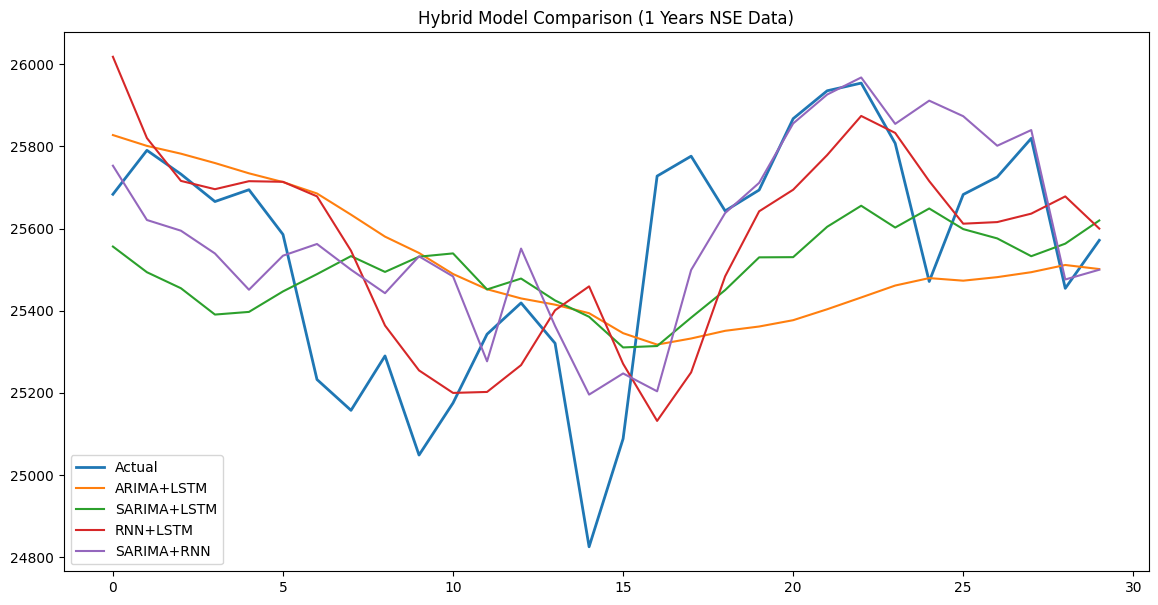

In [9]:
plt.figure(figsize=(14,7))

plt.plot(actual1, label="Actual", linewidth=2)
plt.plot(final_arima_lstm, label="ARIMA+LSTM")
plt.plot(final_sarima_lstm, label="SARIMA+LSTM")
plt.plot(rnn_lstm_pred, label="RNN+LSTM")
plt.plot(final_sarima_rnn, label="SARIMA+RNN")

plt.legend()
plt.title("Hybrid Model Comparison (1 Years NSE Data)")
plt.show()

In [10]:
def evaluate_model_advanced(actual, predicted, model_name):
    
    actual = np.array(actual).flatten()
    predicted = np.array(predicted).flatten()
    
    # Errors
    errors = actual - predicted
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs(errors / actual)) * 100
    
    # Volatility (returns std deviation)
    returns_actual = np.diff(actual) / actual[:-1]
    returns_pred = np.diff(predicted) / predicted[:-1]
    
    volatility_actual = np.std(returns_actual)
    volatility_pred = np.std(returns_pred)

    # Convert to direction (1 = Up, 0 = Down)
    actual_direction = np.where(np.diff(actual) > 0, 1, 0)
    pred_direction = np.where(np.diff(predicted) > 0, 1, 0)
    
    accuracy = accuracy_score(actual_direction, pred_direction)
    precision = precision_score(actual_direction, pred_direction)
    recall = recall_score(actual_direction, pred_direction)
    f1 = f1_score(actual_direction, pred_direction)
    
    cm = confusion_matrix(actual_direction, pred_direction)
    
    print(f"\n===== {model_name} =====")
    print("RMSE :", rmse)
    print("MAE  :", mae)
    print("R2   :", r2)
    print("MAPE :", mape)
    print("Actual Volatility :", volatility_actual)
    print("Predicted Volatility :", volatility_pred)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("Confusion Matrix:\n", cm)
    
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape,
        "Actual_Volatility": volatility_actual,
        "Predicted_Volatility": volatility_pred,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    }, errors

In [11]:
metrics1, errors1 = evaluate_model_advanced(actual1, final_arima_lstm, "ARIMA + LSTM")
metrics2, errors2 = evaluate_model_advanced(actual2, final_sarima_lstm, "SARIMA + LSTM")
metrics3, errors3 = evaluate_model_advanced(actual3, rnn_lstm_pred, "RNN + LSTM")
metrics4, errors4 = evaluate_model_advanced(actual4, final_sarima_rnn, "SARIMA + RNN")


===== ARIMA + LSTM =====
RMSE : 316.73264886108586
MAE  : 260.3995877049479
R2   : -0.23717824820193423
MAPE : 1.020565506671377
Actual Volatility : 0.008706201369504486
Predicted Volatility : 0.001014075698269477
Accuracy : 0.5172413793103449
Precision: 0.6363636363636364
Recall   : 0.4117647058823529
F1 Score : 0.5
Confusion Matrix:
 [[ 8  4]
 [10  7]]

===== SARIMA + LSTM =====
RMSE : 274.9773880678908
MAE  : 244.64584530886108
R2   : 0.067517747422836
MAPE : 0.9592347560465814
Actual Volatility : 0.008706201369504486
Predicted Volatility : 0.0019897220019251274
Accuracy : 0.5172413793103449
Precision: 0.5882352941176471
Recall   : 0.5882352941176471
F1 Score : 0.5882352941176471
Confusion Matrix:
 [[ 5  7]
 [ 7 10]]

===== RNN + LSTM =====
RMSE : 251.34754105947
MAE  : 183.8261328124998
R2   : 0.2208951788615544
MAPE : 0.7223306314411416
Actual Volatility : 0.008706201369504478
Predicted Volatility : 0.004238301
Accuracy : 0.6206896551724138
Precision: 0.7142857142857143
Recall   

In [12]:
results_df = pd.DataFrame([metrics1, metrics2, metrics3, metrics4])

print("\n===== Final Model Comparison =====")
print(results_df)

# Sort by RMSE (best first)
results_df = results_df.sort_values("RMSE")
print("\nBest Model Based on RMSE:")
print(results_df.iloc[0])


===== Final Model Comparison =====
           Model        RMSE         MAE        R2      MAPE  \
0   ARIMA + LSTM  316.732649  260.399588 -0.237178  1.020566   
1  SARIMA + LSTM  274.977388  244.645845  0.067518  0.959235   
2     RNN + LSTM  251.347541  183.826133  0.220895  0.722331   
3   SARIMA + RNN  222.862539  163.634248  0.387479  0.644137   

   Actual_Volatility  Predicted_Volatility  Accuracy  Precision    Recall  \
0           0.008706              0.001014  0.517241   0.636364  0.411765   
1           0.008706              0.001990  0.517241   0.588235  0.588235   
2           0.008706              0.004238  0.620690   0.714286  0.588235   
3           0.008706              0.005316  0.551724   0.642857  0.529412   

   F1_Score  
0  0.500000  
1  0.588235  
2  0.645161  
3  0.580645  

Best Model Based on RMSE:
Model                   SARIMA + RNN
RMSE                      222.862539
MAE                       163.634248
R2                          0.387479
MAPE        

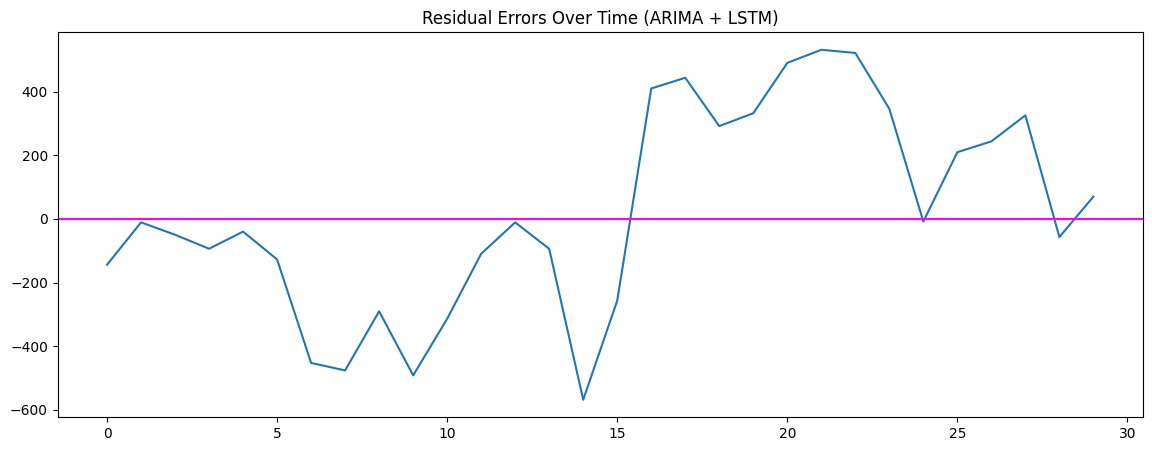

In [13]:
plt.figure(figsize=(14,5))
plt.plot(errors1)
plt.title("Residual Errors Over Time (ARIMA + LSTM)")
plt.axhline(0, color='magenta')
plt.show()

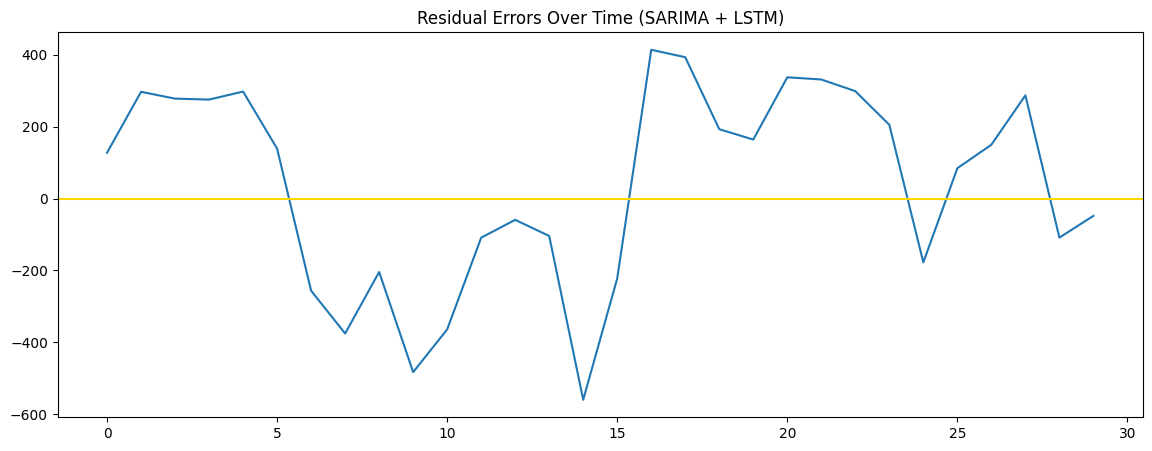

In [14]:
plt.figure(figsize=(14,5))
plt.plot(errors2)
plt.title("Residual Errors Over Time (SARIMA + LSTM)")
plt.axhline(0, color='gold')
plt.show()

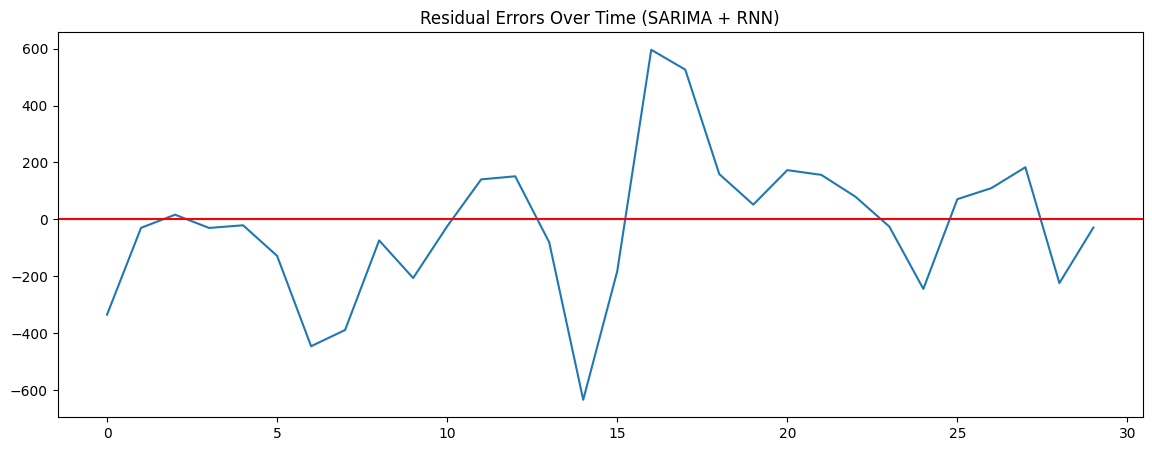

In [15]:
plt.figure(figsize=(14,5))
plt.plot(errors3)
plt.title("Residual Errors Over Time (SARIMA + RNN)")
plt.axhline(0, color='red')
plt.show()

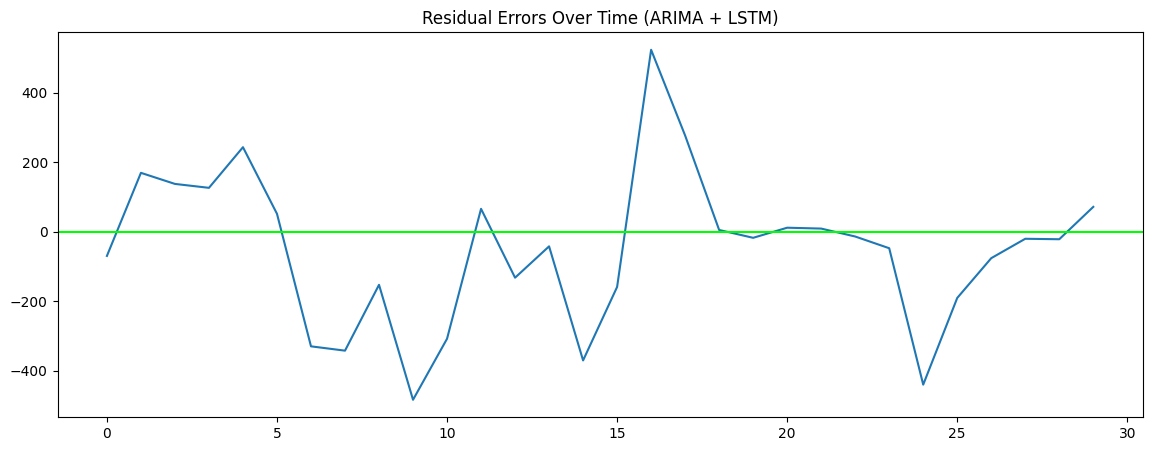

In [16]:
plt.figure(figsize=(14,5))
plt.plot(errors4)
plt.title("Residual Errors Over Time (ARIMA + LSTM)")
plt.axhline(0, color='lime')
plt.show()

In [17]:
prediction_df = pd.DataFrame({
    "Actual": actual1,
    "Predicted_ARIMA_LSTM": final_arima_lstm
})

print(prediction_df.head())

     Actual  Predicted_ARIMA_LSTM
0  25683.30          25827.389302
1  25790.25          25801.032780
2  25732.30          25782.070597
3  25665.60          25759.298490
4  25694.35          25734.281725


In [18]:
prediction_df = pd.DataFrame({
    "Actual": actual2,
    "Predicted_SARIMA_LSTM": final_sarima_lstm
})

print(prediction_df.head())

     Actual  Predicted_SARIMA_LSTM
0  25683.30           25556.089353
1  25790.25           25493.591914
2  25732.30           25454.583123
3  25665.60           25390.561320
4  25694.35           25397.024892


In [19]:
prediction_df = pd.DataFrame({
    "Actual": actual3.flatten(),
    "Predicted_RNN_LSTM": rnn_lstm_pred.flatten()
})

print(prediction_df.head())

     Actual  Predicted_RNN_LSTM
0  25683.30        26017.902344
1  25790.25        25819.998047
2  25732.30        25715.843750
3  25665.60        25695.667969
4  25694.35        25715.144531


In [20]:
prediction_df = pd.DataFrame({
    "Actual": actual4,
    "Predicted_SARIMA_RNN": final_sarima_rnn
})

print(prediction_df.head())

     Actual  Predicted_SARIMA_RNN
0  25683.30          25752.842832
1  25790.25          25620.695063
2  25732.30          25594.633721
3  25665.60          25539.207682
4  25694.35          25450.986501


In [21]:
import numpy as np

def predict_future_prices(model, last_data, scaler, time_steps, future_days):
    
    # Ensure correct shape
    input_seq = last_data[-time_steps:]
    input_seq = input_seq.reshape(1, time_steps, 1)

    future_predictions = []

    for _ in range(future_days):
        
        pred = model.predict(input_seq, verbose=0)
        
        # Store prediction
        future_predictions.append(pred[0, 0])
        
        # Reshape prediction properly to (1,1,1)
        pred_reshaped = pred.reshape(1, 1, 1)
        
        # Remove first timestep and append prediction
        input_seq = np.concatenate(
            (input_seq[:, 1:, :], pred_reshaped),
            axis=1
        )

    # Convert back to original scale
    future_predictions = scaler.inverse_transform(
        np.array(future_predictions).reshape(-1, 1)
    )

    return future_predictions.flatten()

In [22]:
future_days = 10

future_prices = predict_future_prices(
    model3,
    test_scaled,
    scaler,
    time_steps,
    future_days
)

print("Future Prices:", future_prices)

Future Prices: [25552.078 25529.088 25542.688 25522.193 25544.    25550.594 25565.662
 25585.566 25596.574 25587.58 ]


In [23]:
last_date = df.index[-1]
future_dates = pd.date_range(last_date, periods=future_days+1)[1:]

future_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Price": future_prices
})

print(future_df)

        Date  Predicted_Price
0 2026-02-21     25552.078125
1 2026-02-22     25529.087891
2 2026-02-23     25542.687500
3 2026-02-24     25522.193359
4 2026-02-25     25544.000000
5 2026-02-26     25550.593750
6 2026-02-27     25565.662109
7 2026-02-28     25585.566406
8 2026-03-01     25596.574219
9 2026-03-02     25587.580078


#### Final Training & Comparison

In [24]:
time_steps = 30

# --- SARIMA ---
sarima_model = SARIMAX(train['Close'],
                       order=(4,0,3),
                       seasonal_order=(1,0,1,5))

sarima_result = sarima_model.fit()

forecast = sarima_result.forecast(steps=len(test))

# --- Residuals ---
residuals = test['Close'].values - forecast.values
residuals = residuals.reshape(-1,1)

# --- Scaling ---
from sklearn.preprocessing import StandardScaler
scaler_res = StandardScaler()
res_scaled = scaler_res.fit_transform(residuals)

X_res, y_res = create_sequences(res_scaled, time_steps)

# --- RNN ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model = Sequential([
    SimpleRNN(61, return_sequences=True, input_shape=(time_steps,1)),
    Dropout(0.2),
    SimpleRNN(32),
    Dense(1)
])

model.compile(optimizer=Adam(0.0005), loss='huber')

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

model.fit(X_res, y_res,
          epochs=150,
          batch_size=16,
          callbacks=[early_stop],
          verbose=0)

# --- Prediction ---
pred = model.predict(X_res)
pred = scaler_res.inverse_transform(pred)

final_pred = forecast[time_steps:].values + pred.flatten()
actual = test['Close'].values[time_steps:]

C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will 

1/1 [==============================] - 0s 182ms/step


In [25]:
# Evaludate Properly 
metrics_opt, _ = evaluate_model_advanced(actual, final_pred, "PSO SARIMA+RNN")


===== PSO SARIMA+RNN =====
RMSE : 31.257906461405263
MAE  : 23.153775028371818
R2   : 0.9885959473579236
MAPE : 0.09095001255805017
Actual Volatility : 0.00971264880076248
Predicted Volatility : 0.008984875670706268
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Confusion Matrix:
 [[ 6  0]
 [ 0 13]]


In [26]:
final_results = pd.DataFrame([
    metrics1,   # ARIMA+LSTM
    metrics2,   # SARIMA+LSTM
    metrics3,   # RNN+LSTM
    metrics4,   # OLD SARIMA+RNN
    metrics_opt # NEW PSO SARIMA+RNN
])

print(final_results.sort_values("RMSE"))

            Model        RMSE         MAE        R2      MAPE  \
4  PSO SARIMA+RNN   31.257906   23.153775  0.988596  0.090950   
3    SARIMA + RNN  222.862539  163.634248  0.387479  0.644137   
2      RNN + LSTM  251.347541  183.826133  0.220895  0.722331   
1   SARIMA + LSTM  274.977388  244.645845  0.067518  0.959235   
0    ARIMA + LSTM  316.732649  260.399588 -0.237178  1.020566   

   Actual_Volatility  Predicted_Volatility  Accuracy  Precision    Recall  \
4           0.009713              0.008985  1.000000   1.000000  1.000000   
3           0.008706              0.005316  0.551724   0.642857  0.529412   
2           0.008706              0.004238  0.620690   0.714286  0.588235   
1           0.008706              0.001990  0.517241   0.588235  0.588235   
0           0.008706              0.001014  0.517241   0.636364  0.411765   

   F1_Score  
4  1.000000  
3  0.580645  
2  0.645161  
1  0.588235  
0  0.500000  


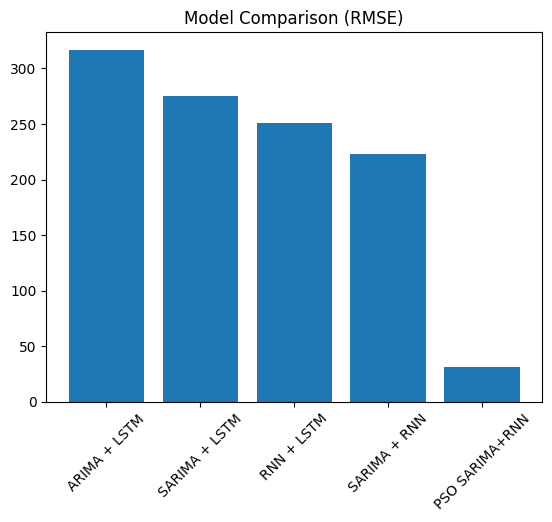

In [27]:
import matplotlib.pyplot as plt

plt.bar(final_results['Model'], final_results['RMSE'])
plt.xticks(rotation=45)
plt.title("Model Comparison (RMSE)")
plt.show()

In [28]:
future_days = 10  # no of days for prediction

future_prices = predict_future_prices(
    model,
    test_scaled,
    scaler,
    time_steps,
    future_days
)

print("Future Prices:", future_prices)

Future Prices: [21033.426 19611.473 19988.62  20518.209 20311.975 18758.379 18924.904
 19749.496 18630.8   16317.418]


In [29]:
last_date = df.index[-1]
future_dates = pd.date_range(last_date, periods=future_days+1)[1:]

future_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Price": future_prices
})

print(future_df)

        Date  Predicted_Price
0 2026-02-21     21033.425781
1 2026-02-22     19611.472656
2 2026-02-23     19988.619141
3 2026-02-24     20518.208984
4 2026-02-25     20311.974609
5 2026-02-26     18758.378906
6 2026-02-27     18924.904297
7 2026-02-28     19749.496094
8 2026-03-01     18630.800781
9 2026-03-02     16317.417969
